## Librerías y carga del modelo

Cargamos el modelo XGBoost entrenado y los conjuntos de train/test del notebook 03.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

# Cargar modelo entrenado
xgb_model = joblib.load('../models/xgboost_model.pkl')

# Cargar datos
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Modelo cargado: {type(xgb_model).__name__}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Features: {X_train.shape[1]} columnas")

# Configurar visualización
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})
shap.initjs()

Modelo cargado: XGBClassifier
X_train: (954, 31), X_test: (185, 31)
Features: 31 columnas


## Cálculo de SHAP values

Usamos `TreeExplainer` porque es el método optimizado para modelos basados en árboles 
como XGBoost (mucho más rápido y exacto que el explainer genérico).

Los SHAP values nos dicen, para cada predicción individual, cuánto contribuyó cada 
feature a llevar la predicción hacia "acquired" (valor positivo) o hacia "closed" 
(valor negativo).

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print(f"Forma de shap_values: {shap_values.shape}")
print(f" → {shap_values.shape[0]} muestras de test")
print(f" → {shap_values.shape[1]} features")
print(f"\nValor esperado del modelo (base value): {explainer.expected_value:.4f}")

Forma de shap_values: (185, 31)
 → 185 muestras de test
 → 31 features

Valor esperado del modelo (base value): -0.0140


## Importancia global de features

El summary plot muestra los features ordenados por importancia global. Cada punto 
representa una muestra del test set:
- **Color rojo:** valor alto del feature
- **Color azul:** valor bajo del feature
- **Eje X:** impacto en la predicción (positivo → empuja a "acquired", negativo → "closed")

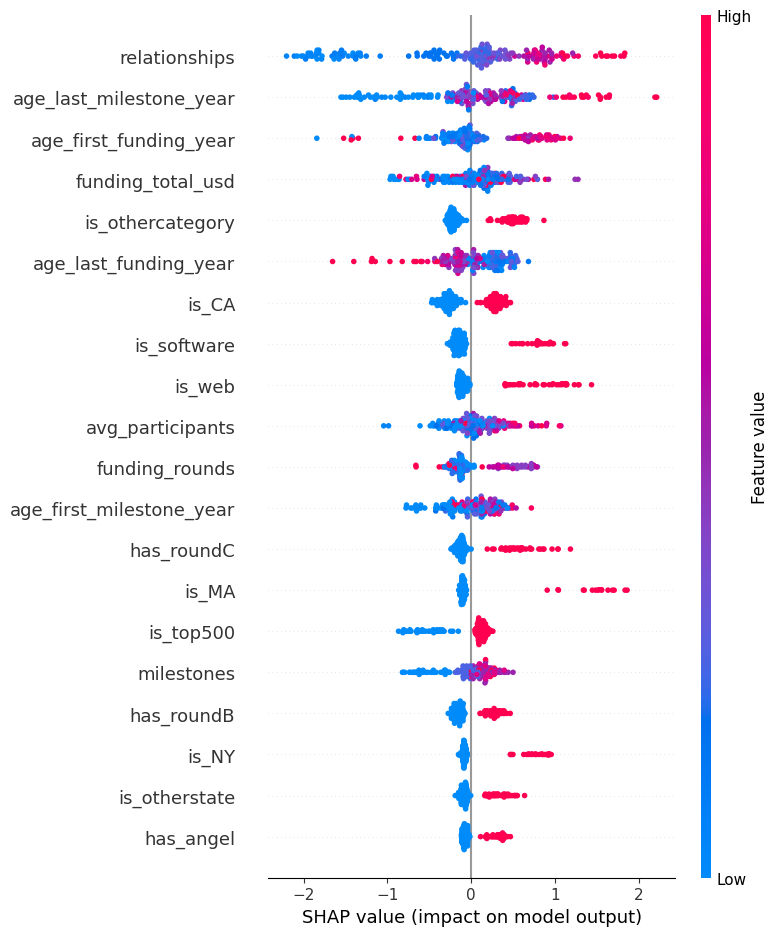

In [ ]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../docs/fig_06_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()

### Hallazgos del summary plot

**Top 3 features más importantes:**

1. **`relationships`** — el predictor más fuerte. Más conexiones empujan hacia "acquired".
2. **`age_last_milestone_year`** — startups con milestones recientes tienen más probabilidad de éxito.
3. **`age_first_funding_year`** — recibir funding muy temprano no es necesariamente positivo.

**Otros hallazgos relevantes:**

- **Ubicación importa:** Estar en California (`is_CA`) o Massachusetts (`is_MA`) impulsa la predicción hacia éxito.
- **Tipo de industria:** Software (`is_software`) y web (`is_web`) son los sectores con mayor impacto positivo.
- **Etapas de funding:** Tener rondas B (`has_roundB`) y C (`has_roundC`) son señales fuertes de éxito.
- **`is_top500`** tiene impacto positivo pero moderado.

Estos hallazgos son consistentes con la intuición del dominio: startups bien conectadas, 
activas, ubicadas en ecosistemas tecnológicos y que logran avanzar en rondas de funding 
tienen mayor probabilidad de ser adquiridas.

## Importancia global resumida

Vista alternativa del summary plot, más limpia. Ordena los features por la magnitud 
promedio de sus SHAP values (sin considerar dirección). Útil para presentaciones e 
informes.

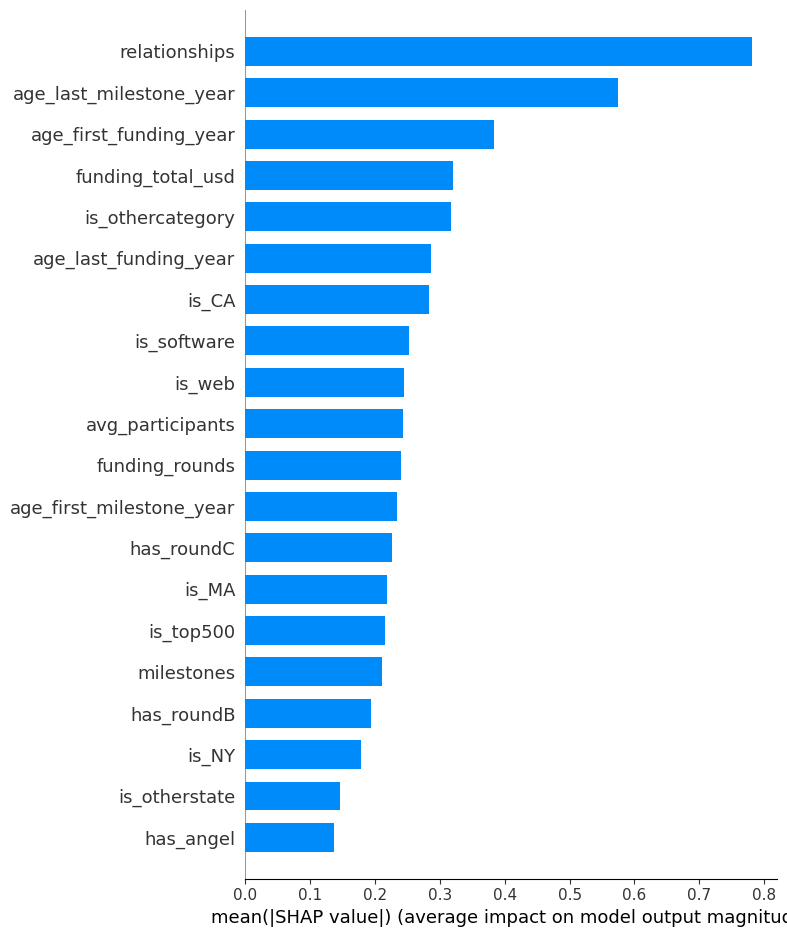

In [10]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

## Explicaciones locales (Waterfall Plots)

Mientras el summary plot muestra patrones globales, el waterfall plot explica una 
predicción individual. Para cada startup, muestra:

- El **valor base** (punto de partida del modelo).
- Las contribuciones de cada feature (positivas o negativas).
- El **valor final** que lleva a la predicción.

Vamos a generar waterfall plots para tres casos representativos: una startup que el 
modelo predice como "acquired" con alta confianza, una como "closed", y un caso 
intermedio (incierto).

In [ ]:
# Probabilidades predichas en test
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 3 casos representativos
idx_acquired_alto = np.argmax(y_proba)
idx_closed_alto = np.argmin(y_proba)
idx_incierto = np.argmin(np.abs(y_proba - 0.5))

print(f"Caso 1 - Alta confianza ACQUIRED:")
print(f"  Índice: {idx_acquired_alto}, Probabilidad: {y_proba[idx_acquired_alto]:.4f}, Real: {y_test.iloc[idx_acquired_alto]}")

print(f"\nCaso 2 - Alta confianza CLOSED:")
print(f"  Índice: {idx_closed_alto}, Probabilidad: {y_proba[idx_closed_alto]:.4f}, Real: {y_test.iloc[idx_closed_alto]}")

print(f"\nCaso 3 - Predicción INCIERTA:")
print(f"  Índice: {idx_incierto}, Probabilidad: {y_proba[idx_incierto]:.4f}, Real: {y_test.iloc[idx_incierto]}")

Caso 1 - Alta confianza ACQUIRED:
  Índice: 88, Probabilidad: 0.9966, Real: 1

Caso 2 - Alta confianza CLOSED:
  Índice: 86, Probabilidad: 0.0011, Real: 0

Caso 3 - Predicción INCIERTA:
  Índice: 133, Probabilidad: 0.5075, Real: 1


CASO 1 — Alta confianza ACQUIRED (idx=88)
Probabilidad: 0.9966 | Real: 1


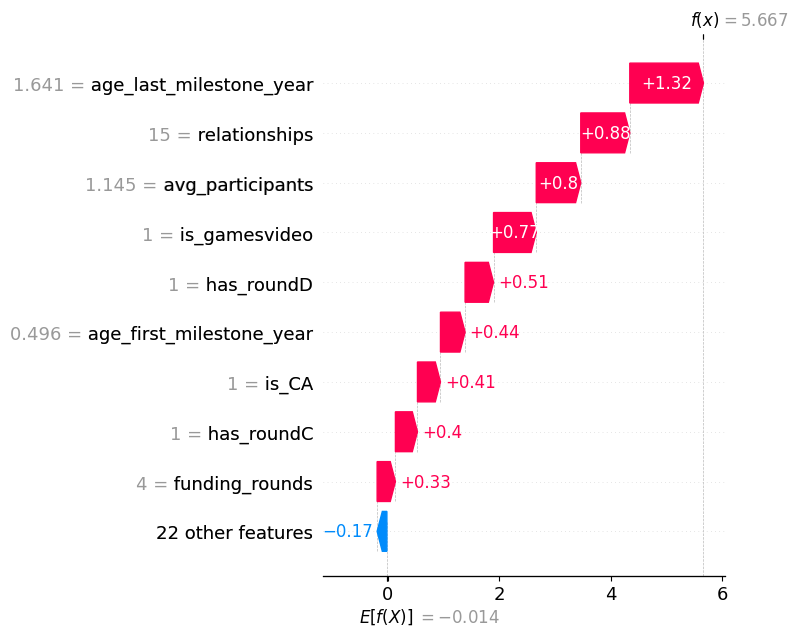

In [16]:
print(f"CASO 1 — Alta confianza ACQUIRED (idx={idx_acquired_alto})")
print(f"Probabilidad: {y_proba[idx_acquired_alto]:.4f} | Real: {y_test.iloc[idx_acquired_alto]}")

shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_acquired_alto],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_acquired_alto].values,
    feature_names=X_test.columns.tolist()
), show=False)
plt.tight_layout()
plt.show()

CASO 2 — Alta confianza CLOSED (idx=86)
Probabilidad: 0.0011 | Real: 0


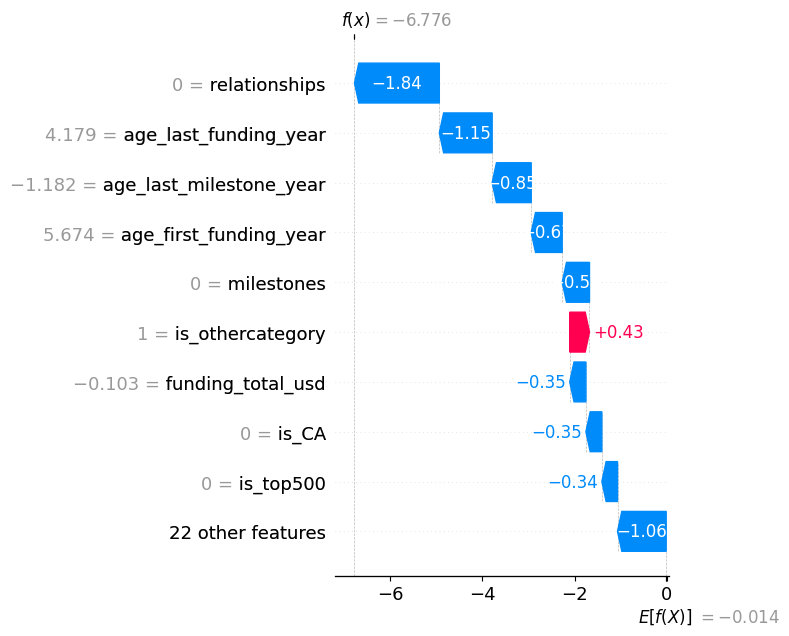

In [20]:
print(f"CASO 2 — Alta confianza CLOSED (idx={idx_closed_alto})")
print(f"Probabilidad: {y_proba[idx_closed_alto]:.4f} | Real: {y_test.iloc[idx_closed_alto]}")

shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_closed_alto],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_closed_alto].values,
    feature_names=X_test.columns.tolist()
), show=False)
plt.tight_layout()
plt.show()

CASO 3 — Predicción INCIERTA (idx=133)
Probabilidad: 0.5075 | Real: 1


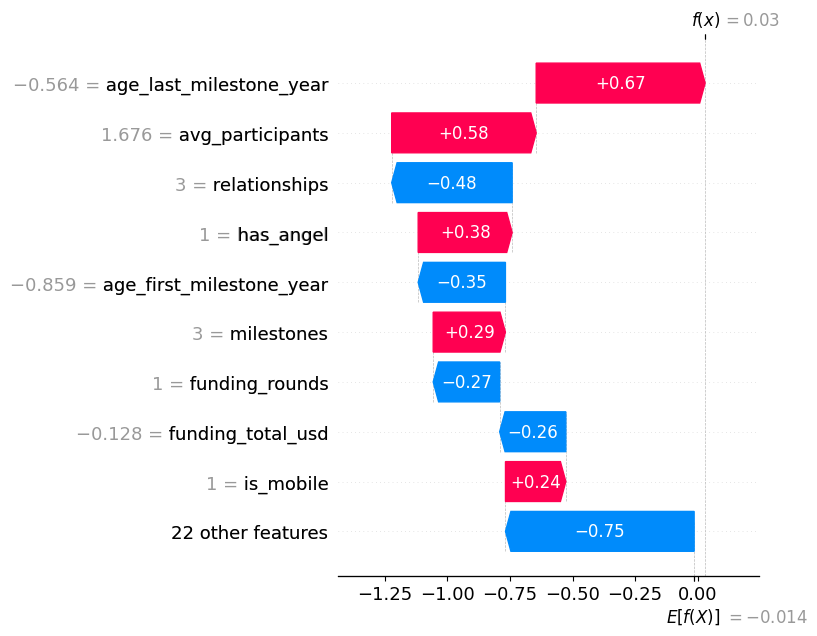

In [23]:
print(f"CASO 3 — Predicción INCIERTA (idx={idx_incierto})")
print(f"Probabilidad: {y_proba[idx_incierto]:.4f} | Real: {y_test.iloc[idx_incierto]}")

shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_incierto],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx_incierto].values,
    feature_names=X_test.columns.tolist()
), show=False)
plt.tight_layout()
plt.show()

In [25]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Guardar SHAP values como CSV
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df.to_csv('../data/processed/shap_values_test.csv', index=False)

with open('../data/processed/shap_base_value.txt', 'w') as f:
    f.write(str(explainer.expected_value))

# Guardar las probabilidades
proba_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': xgb_model.predict(X_test),
    'y_proba': y_proba
})
proba_df.to_csv('../data/processed/predictions_test.csv', index=False)

print("Archivos exportados:")
print(f" shap_values_test.csv → {shap_df.shape}")
print(f" shap_base_value.txt → {explainer.expected_value:.6f}")
print(f" predictions_test.csv → {proba_df.shape}")

Archivos exportados:
 shap_values_test.csv → (185, 31)
 shap_base_value.txt → -0.013956
 predictions_test.csv → (185, 3)


## Conclusiones del notebook 04

**Importancia global (SHAP):** Los 5 features más influyentes son `relationships`, `age_last_milestone_year`, `age_first_funding_year`, `funding_total_usd` e `is_otherCategory`. El número de relaciones domina con un impacto promedio casi 50% mayor que el segundo.

**Explicaciones locales:** Se analizaron 3 casos (acquired con 99.66%, closed con 0.11%, incierto con 50.75%). Los waterfall plots muestran cómo cada feature contribuye individualmente a la predicción final.

**Artefactos exportados:**
- `shap_values_test.csv` — SHAP values por muestra
- `shap_base_value.txt` — valor base del modelo
- `predictions_test.csv` — predicciones y probabilidades

Estos archivos permiten construir explicaciones en lenguaje natural a partir de los top SHAP values de cada predicción, conectando la salida cuantitativa del modelo con interpretaciones comprensibles para un inversionista.